# D7 — Statistical Analysis of BIS Macroeconomic Time Series

## Objective

In the previous notebooks, we learned how to discover BIS SDMX metadata, retrieve official macroeconomic data, and build analysis-ready datasets.

The objective of this notebook is to move beyond data preparation and focus on **understanding the statistical characteristics of a macroeconomic time series**.

Using the BIS Total Credit dataset, we will investigate how economists and data scientists examine a time series before selecting forecasting or econometric models.

Rather than predicting future values, this notebook emphasizes exploratory statistical analysis, trend identification, growth measurement, volatility assessment, and stationarity diagnostics.

---

## Learning Objectives

By the end of this notebook, we will be able to:

- Retrieve a BIS SDMX time series
- Build an analysis-ready dataset
- Compute descriptive statistics
- Analyze rolling trends and volatility
- Measure quarter-on-quarter and year-on-year growth
- Examine the statistical distribution of the series
- Evaluate autocorrelation
- Test for stationarity using standard statistical tests
- Interpret the statistical behaviour of macroeconomic data

---

## Workflow

```text
Retrieve BIS SDMX Data
        │
        ▼
Analysis-Ready Dataset
        │
        ▼
Descriptive Statistics
        │
        ▼
Rolling Trend Analysis
        │
        ▼
Growth Rate Analysis
        │
        ▼
Distribution Analysis
        │
        ▼
Autocorrelation Analysis
        │
        ▼
Stationarity Diagnostics
        │
        ▼
Economic Interpretation
```

In [1]:
# ----------------------------------------------------
# Imports
# ----------------------------------------------------

import sdmx
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew
from scipy.stats import kurtosis

from statsmodels.tsa.stattools import adfuller

plt.rcParams["figure.figsize"] = (12, 5)

In [6]:
# ----------------------------------------------------
# Analysis Configuration
# ----------------------------------------------------

DATAFLOW_ID = "WS_TC"

COUNTRY = "IN"

BORROWER = "P"

LENDER = "A"

VALUATION = "M"

UNIT = "770"

ADJUSTMENT = "A"

FREQUENCY = "Q"

In [8]:
# ----------------------------------------------------
# Connect to BIS
# ----------------------------------------------------

client = sdmx.Client("BIS")

print(client.source.id)
print(client.source.url)

BIS
https://stats.bis.org/api/v1


In [9]:
# ----------------------------------------------------
# Retrieve Data
# ----------------------------------------------------

query_key = (
    f"{FREQUENCY}."
    f"{COUNTRY}."
    f"{BORROWER}."
    f"{LENDER}."
    f"{VALUATION}."
    f"{UNIT}."
    f"{ADJUSTMENT}"
)

print(query_key)

response = client.data(
    "WS_TC",
    key=query_key
)

dataset = response.data[0]

print("Series :", len(dataset.series))
print("Observations :", len(dataset.obs))

Q.IN.P.A.M.770.A


xml.Reader got no structure=… argument for StructureSpecificData


Series : 1
Observations : 299


In [11]:
type(dataset)

sdmx.model.v21.StructureSpecificDataSet

In [12]:
# ----------------------------------------------------
# Build Analysis Dataset
# ----------------------------------------------------

rows = []

for series_key, observations in dataset.series.items():

    metadata = {
        dim: value.value
        for dim, value in series_key.values.items()
    }

    for obs in observations:

        row = metadata.copy()

        row["TIME_PERIOD"] = obs.dimension.values[0].value
        row["OBS_VALUE"] = float(obs.value)

        rows.append(row)

df = pd.DataFrame(rows)

df["Quarter"] = pd.PeriodIndex(
    df["TIME_PERIOD"],
    freq="Q"
)

df["Year"] = df["Quarter"].dt.year

df = df.sort_values("Quarter").reset_index(drop=True)

print(df.shape)
display(df.head())

(299, 14)


,BORROWERS_CTY,TC_BORROWERS,TC_LENDERS,VALUATION,UNIT_TYPE,TC_ADJUST,FREQ,TITLE_TS,UNIT_MULT,UNIT_MEASURE,TIME_PERIOD,OBS_VALUE,Quarter,Year
0,IN,P,A,M,770,A,Q,India - Credit to Private non-financial sector...,0,367,1951-Q2,25.2,1951Q2,1951
1,IN,P,A,M,770,A,Q,India - Credit to Private non-financial sector...,0,367,1951-Q3,23.4,1951Q3,1951
2,IN,P,A,M,770,A,Q,India - Credit to Private non-financial sector...,0,367,1951-Q4,23.0,1951Q4,1951
3,IN,P,A,M,770,A,Q,India - Credit to Private non-financial sector...,0,367,1952-Q1,23.1,1952Q1,1952
4,IN,P,A,M,770,A,Q,India - Credit to Private non-financial sector...,0,367,1952-Q2,23.3,1952Q2,1952


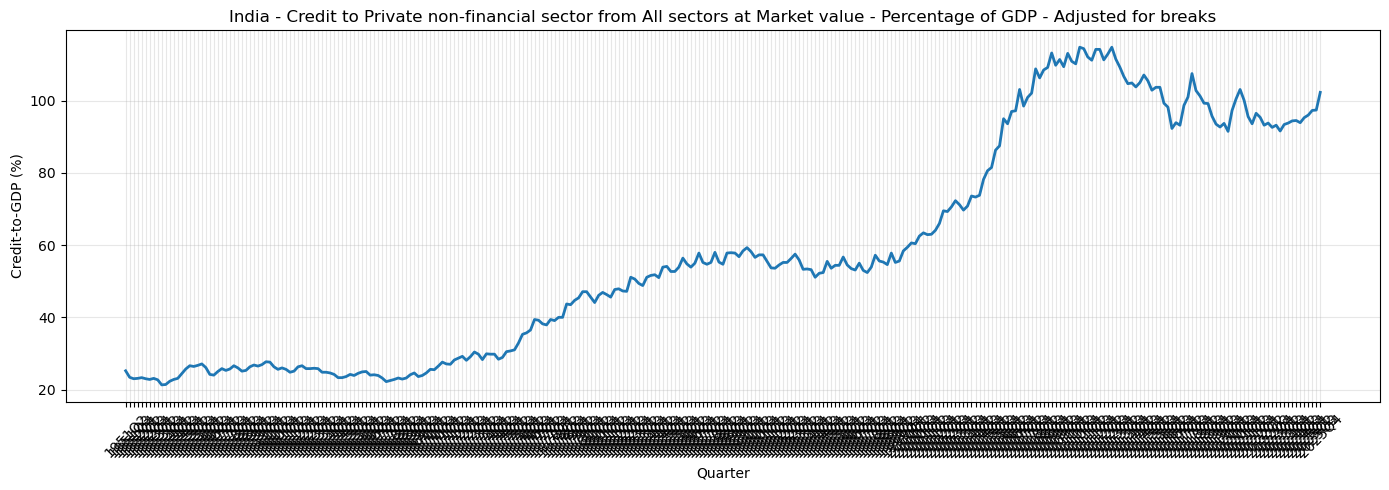

In [14]:
# ----------------------------------------------------
# Credit-to-GDP Time Series
# How has the Credit-to-GDP ratio evolved over time?
# ----------------------------------------------------

plt.figure(figsize=(14,5))

plt.plot(
    df["Quarter"].astype(str),
    df["OBS_VALUE"],
    linewidth=2
)

plt.title(df["TITLE_TS"].iloc[0])

plt.xlabel("Quarter")
plt.ylabel("Credit-to-GDP (%)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ----------------------------------------------------
# Statistical Summary
# What are the basic characteristics of this series?
# ----------------------------------------------------

summary = pd.Series({

    "Observations": len(df),

    "Start": str(df["Quarter"].min()),

    "End": str(df["Quarter"].max()),

    "Mean": df["OBS_VALUE"].mean(),

    "Median": df["OBS_VALUE"].median(),

    "Minimum": df["OBS_VALUE"].min(),

    "Maximum": df["OBS_VALUE"].max(),

    "Standard Deviation": df["OBS_VALUE"].std(),

    "Variance": df["OBS_VALUE"].var(),

    "Skewness": skew(df["OBS_VALUE"]),

    "Kurtosis": kurtosis(df["OBS_VALUE"])

})

summary.round(2)